# <font size="4"> Import dependencies </font>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load and open results.csv
csv_path = "C:/Users/akara/OneDrive/Desktop/D_Chatz/3D-Heritage-Mapper/projects/auth/models/YOLO26_test_1/results.csv"
df = pd.read_csv(csv_path, sep=';')

df.columns = df.columns.str.strip()

# 4. Επιβεβαίωση φόρτωσης και γρήγορο preview των δεδομένων
print(f"Επιτυχής φόρτωση! Το dataset περιλαμβάνει {len(df)} εποχές εκπαίδευσης.")
print("\nΟι διαθέσιμες στήλες για την ανάλυσή μας είναι:")
for col in df.columns:
    print(f" - {col}")

df.tail()

Επιτυχής φόρτωση! Το dataset περιλαμβάνει 150 εποχές εκπαίδευσης.

Οι διαθέσιμες στήλες για την ανάλυσή μας είναι:
 - epoch
 - time
 - train/box_loss
 - train/cls_loss
 - train/dfl_loss
 - metrics/precision(B)
 - metrics/recall(B)
 - metrics/mAP50(B)
 - metrics/mAP50-95(B)
 - val/box_loss
 - val/cls_loss
 - val/dfl_loss
 - lr/pg0
 - lr/pg1
 - lr/pg2


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
145,146,4314.92,1.3579,0.7800,0.0040,0.7852,0.6392,0.6785,0.4500,1.5217,1.1906,0.005,0.0001,0.0001,0.0001
146,147,4345.12,1.3519,0.7846,0.0039,0.7697,0.6469,0.6760,0.4483,1.5253,1.1942,0.005,0.0001,0.0001,0.0001
147,148,4375.13,1.3498,0.7922,0.0040,0.7699,0.6497,0.6779,0.4502,1.5273,1.1899,0.005,0.0000,0.0000,0.0000
148,149,4405.30,1.3422,0.7934,0.0040,0.7856,0.6415,0.6793,0.4509,1.5196,1.1972,0.005,0.0000,0.0000,0.0000
149,150,4435.43,1.3498,0.7820,0.0039,0.7776,0.6406,0.6770,0.4491,1.5324,1.1912,0.005,0.0000,0.0000,0.0000


# <font size="4"> F1-score </font>

In [4]:
#F1 = 2 * (Precision * Recall)/(Precision + Recall)

P = df['metrics/precision(B)']
R = df['metrics/recall(B)']
F1 = 2 * ((P*R)/(P+R))
df['metrics/F1-score'] = F1.round(4)
df.tail()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,metrics/F1-score
145,146,4314.92,1.3579,0.7800,0.0040,0.7852,0.6392,0.6785,0.4500,1.5217,1.1906,0.005,0.0001,0.0001,0.0001,0.7047
146,147,4345.12,1.3519,0.7846,0.0039,0.7697,0.6469,0.6760,0.4483,1.5253,1.1942,0.005,0.0001,0.0001,0.0001,0.7030
147,148,4375.13,1.3498,0.7922,0.0040,0.7699,0.6497,0.6779,0.4502,1.5273,1.1899,0.005,0.0000,0.0000,0.0000,0.7047
148,149,4405.30,1.3422,0.7934,0.0040,0.7856,0.6415,0.6793,0.4509,1.5196,1.1972,0.005,0.0000,0.0000,0.0000,0.7063
149,150,4435.43,1.3498,0.7820,0.0039,0.7776,0.6406,0.6770,0.4491,1.5324,1.1912,0.005,0.0000,0.0000,0.0000,0.7025


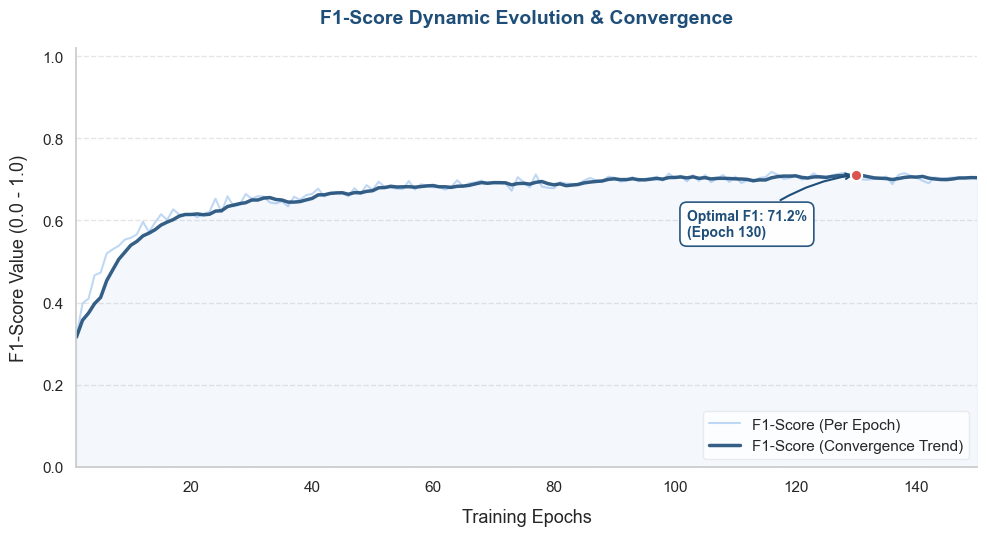

In [5]:

# 1. Compute Moving Average (5-epoch window) for curve smoothing
df['metrics/F1-score_smooth'] = df['metrics/F1-score'].rolling(window=5, min_periods=1).mean()

# 2. Set academic publication style
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Add soft horizontal gridlines only
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# 3. Plot raw epoch-by-epoch F1 curve (semi-transparent)
ax.plot(df['epoch'], df['metrics/F1-score'], color='#4a90e2', alpha=0.35, linewidth=1.5, label='F1-Score (Per Epoch)')

# 4. Plot smoothed trendline (bold)
ax.plot(df['epoch'], df['metrics/F1-score_smooth'], color='#1f4e79', alpha=0.9, linewidth=2.5, label='F1-Score (Convergence Trend)')

# 5. Add a very soft color gradient fill underneath
ax.fill_between(df['epoch'], df['metrics/F1-score_smooth'], color='#4a90e2', alpha=0.06)

# 6. Locate peak performance based on the stable smoothed line
max_f1 = df['metrics/F1-score_smooth'].max()
smooth_col = 'metrics/f1_score_smooth' if 'metrics/f1_score_smooth' in df.columns else 'metrics/F1-score_smooth'
max_epoch = df.loc[df[smooth_col].idxmax(), 'epoch']

# Draw the peak value dot
ax.scatter(max_epoch, max_f1, color='#d9534f', s=65, zorder=5, edgecolor='white', linewidth=1.5)

# Minimalist callout box for the Best Metric
ax.annotate(
    f'Optimal F1: {max_f1*100:.1f}%\n(Epoch {max_epoch})',
    xy=(max_epoch, max_f1),
    xytext=(max_epoch - 28, max_f1 - 0.15),
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec="#1f4e79", lw=1.2, alpha=0.95),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.15", color="#1f4e79", lw=1.5),
    fontweight='bold',
    fontsize=10,
    color='#1f4e79'
)

# English Titles and Labels
ax.set_title('F1-Score Dynamic Evolution & Convergence', pad=18, fontweight='bold', color='#1f4e79')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('F1-Score Value (0.0 - 1.0)', labelpad=10)

# Clean up axes spines for a modern look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.set_ylim(0, 1.02)
ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Elegant Legend
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()

plt.show()

# <font size="4"> Recall & Precision </font>

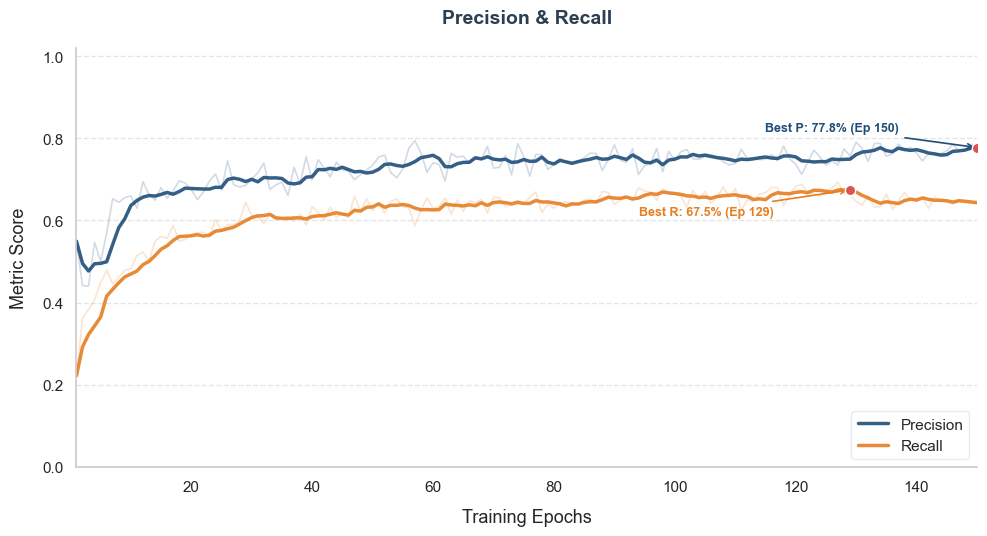

In [6]:
# 1. Compute moving averages (5-epoch window) for smooth visualization
df['metrics/precision_smooth'] = df['metrics/precision(B)'].rolling(window=5, min_periods=1).mean()
df['metrics/recall_smooth'] = df['metrics/recall(B)'].rolling(window=5, min_periods=1).mean()

# 2. Set style settings for clean publication look
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# Colors for our metrics
color_prec = '#1f4e79'  # Deep Blue
color_rec = '#e67e22'   # Coral / Orange

# 3. Plot Precision (Raw & Smoothed)
ax.plot(df['epoch'], df['metrics/precision(B)'], color=color_prec, alpha=0.2, linewidth=1.2)
ax.plot(df['epoch'], df['metrics/precision_smooth'], color=color_prec, alpha=0.9, linewidth=2.5, label='Precision')

# 4. Plot Recall (Raw & Smoothed)
ax.plot(df['epoch'], df['metrics/recall(B)'], color=color_rec, alpha=0.2, linewidth=1.2)
ax.plot(df['epoch'], df['metrics/recall_smooth'], color=color_rec, alpha=0.9, linewidth=2.5, label='Recall')

# 5. Locate Optimal Max Epochs for both metrics
max_p = df['metrics/precision_smooth'].max()
max_p_epoch = df.loc[df['metrics/precision_smooth'].idxmax(), 'epoch']

max_r = df['metrics/recall_smooth'].max()
max_r_epoch = df.loc[df['metrics/recall_smooth'].idxmax(), 'epoch']

# Highlight optimal points with dots
ax.scatter(max_p_epoch, max_p, color='#d9534f', s=55, zorder=5, edgecolor='white')
ax.scatter(max_r_epoch, max_r, color='#d9534f', s=55, zorder=5, edgecolor='white')

# Dynamic annotations for the optimal values
ax.annotate(f'Best P: {max_p*100:.1f}% (Ep {max_p_epoch})', 
            xy=(max_p_epoch, max_p), xytext=(max_p_epoch - 35, max_p + 0.04),
            arrowprops=dict(arrowstyle="->", color=color_prec, lw=1.2),
            fontweight='bold', fontsize=9, color=color_prec)

ax.annotate(f'Best R: {max_r*100:.1f}% (Ep {max_r_epoch})', 
            xy=(max_r_epoch, max_r), xytext=(max_r_epoch - 35, max_r - 0.06),
            arrowprops=dict(arrowstyle="->", color=color_rec, lw=1.2),
            fontweight='bold', fontsize=9, color=color_rec)

# Labels & Titles (Single Y-axis focus)
ax.set_title('Precision & Recall', pad=18, fontweight='bold', color='#2c3e50')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('Metric Score', labelpad=10)

# Clean up layout borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.set_ylim(0, 1.02)
ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Unified clean Legend
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()

plt.show()

# <font size="4"> Overfitting check </font>

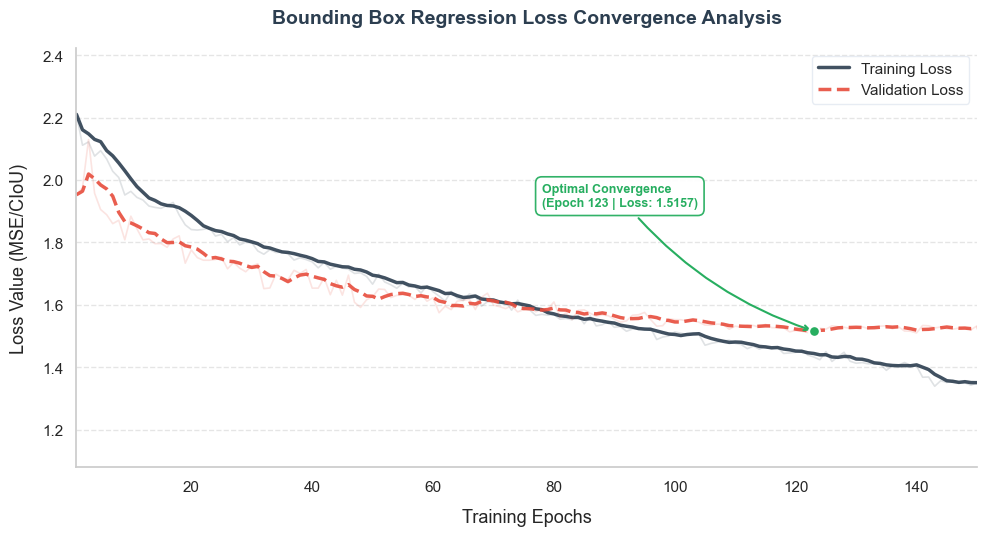

In [ ]:
# 1. Compute moving averages (5-epoch window) for smooth visualization of trends
df['train/box_loss_smooth'] = df['train/box_loss'].rolling(window=5, min_periods=1).mean()
df['val/box_loss_smooth'] = df['val/box_loss'].rolling(window=5, min_periods=1).mean()

# 2. Set academic style settings
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# Theme colors
color_train = '#2c3e50'  # Dark Slate Blue/Grey for Training
color_val = '#e74c3c'    # Bright Red/Coral for Validation

# 3. Plot Training Box Loss (Raw as light background, Smoothed as bold line)
ax.plot(df['epoch'], df['train/box_loss'], color=color_train, alpha=0.15, linewidth=1.2)
ax.plot(df['epoch'], df['train/box_loss_smooth'], color=color_train, alpha=0.9, linewidth=2.5, label='Training Loss')

# 4. Plot Validation Box Loss (Raw as light background, Smoothed as bold dashed line)
ax.plot(df['epoch'], df['val/box_loss'], color=color_val, alpha=0.15, linewidth=1.2)
ax.plot(df['epoch'], df['val/box_loss_smooth'], color=color_val, alpha=0.9, linewidth=2.5, linestyle='--', label='Validation Loss')

# 5. Find the minimum Validation Loss point to showcase optimal convergence
min_val_loss = df['val/box_loss_smooth'].min()
min_val_epoch = df.loc[df['val/box_loss_smooth'].idxmax() if 'val/box_loss_smooth' not in df.columns else df['val/box_loss_smooth'].idxmin(), 'epoch']

# Highlight the lowest validation loss point
ax.scatter(min_val_epoch, min_val_loss, color='#27ae60', s=60, zorder=5, edgecolor='white', linewidth=1.5)

# Minimalist callout box for the point of optimal convergence
ax.annotate(
    f'Optimal Convergence\n(Epoch {min_val_epoch} | Loss: {min_val_loss:.4f})',
    xy=(min_val_epoch, min_val_loss),
    xytext=(min_val_epoch - 45, min_val_loss + 0.4),
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec="#27ae60", lw=1.2, alpha=0.95),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.15", color="#27ae60", lw=1.5),
    fontweight='bold',
    fontsize=9,
    color='#27ae60'
)

# Titles, Labels, and Layout constraints
ax.set_title('Bounding Box Regression Loss Convergence Analysis', pad=18, fontweight='bold', color='#2c3e50')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('Loss Value (MSE/CIoU)', labelpad=10)

# Clean up axes spines for a modern look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Adjust Y-limits automatically with a bit of padding to avoid cutting off annotations
ax.set_ylim(df['train/box_loss_smooth'].min() * 0.8, df['val/box_loss_smooth'].max() * 1.2)

# Unified clean Legend
ax.legend(loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()

plt.show()

# <font size="4"> mAP50 </font>

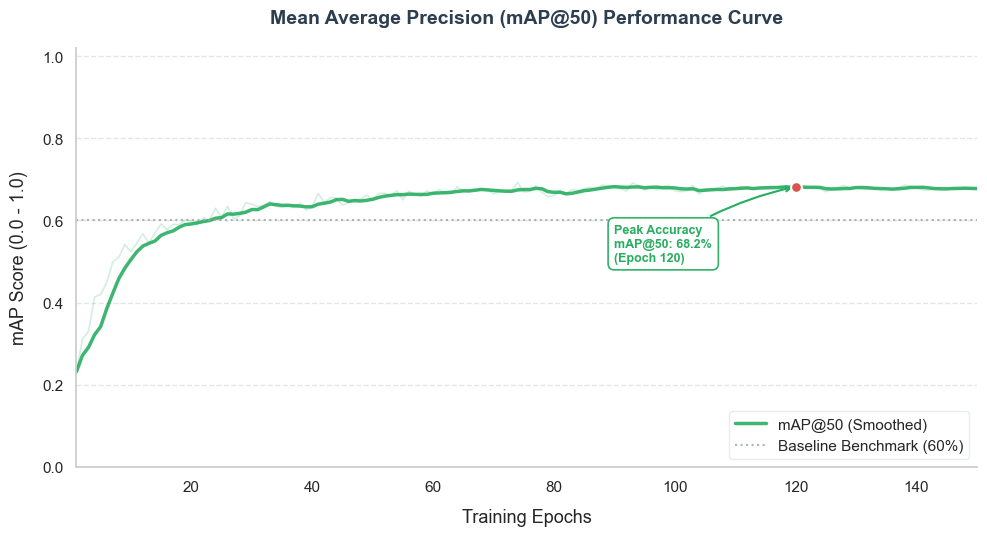

In [19]:
# 1. Compute moving average for mAP50
df['metrics/mAP50_smooth'] = df['metrics/mAP50(B)'].rolling(window=5, min_periods=1).mean()

# 2. Style configuration
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(10, 5.5))

# Soft background grids
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.xaxis.grid(False)

# Theme color for mAP (Emerald Green is great for success metrics)
color_map = '#27ae60'

# 3. Plot raw and smoothed mAP50 curves
ax.plot(df['epoch'], df['metrics/mAP50(B)'], color=color_map, alpha=0.2, linewidth=1.2)
ax.plot(df['epoch'], df['metrics/mAP50_smooth'], color=color_map, alpha=0.9, linewidth=2.5, label='mAP@50 (Smoothed)')

# 4. Add an academic benchmark line (e.g., 60% mark typical for acceptable baseline)
benchmark_val = 0.60
ax.axhline(y=benchmark_val, color='#95a5a6', linestyle=':', alpha=0.8, linewidth=1.5, label=f'Baseline Benchmark ({benchmark_val*100:.0f}%)')

# 5. Locate the absolute highest mAP50 peak
max_map = df['metrics/mAP50_smooth'].max()
max_map_epoch = df.loc[df['metrics/mAP50_smooth'].idxmax(), 'epoch']

# Draw peak indicator
ax.scatter(max_map_epoch, max_map, color='#d9534f', s=60, zorder=5, edgecolor='white', linewidth=1.5)

# Callout annotation text box
ax.annotate(
    f'Peak Accuracy\nmAP@50: {max_map*100:.1f}%\n(Epoch {max_map_epoch})',
    xy=(max_map_epoch, max_map),
    xytext=(max_map_epoch - 30, max_map - 0.18),
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec=color_map, lw=1.2, alpha=0.95),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.1", color=color_map, lw=1.5),
    fontweight='bold',
    fontsize=9,
    color=color_map
)

# Titles, Labels, Spine cleanup
ax.set_title('Mean Average Precision (mAP@50) Performance Curve', pad=18, fontweight='bold', color='#2c3e50')
ax.set_xlabel('Training Epochs', labelpad=10)
ax.set_ylabel('mAP Score (0.0 - 1.0)', labelpad=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.set_ylim(0, 1.02)
ax.set_xlim(df['epoch'].min(), df['epoch'].max())

# Legend
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()
plt.show()

# <font size="4"> Best epoch analysis </font>

🏆 BEST MODEL PERFORMANCE SUMMARY (Epoch 74)
🔹 mAP@50          : 69.25%
🔹 Precision       : 78.71%
🔹 Recall          : 63.93%
🔹 F1-Score        : 70.55%
🔹 Train Box Loss  : 1.61
🔹 Val Box Loss    : 1.58


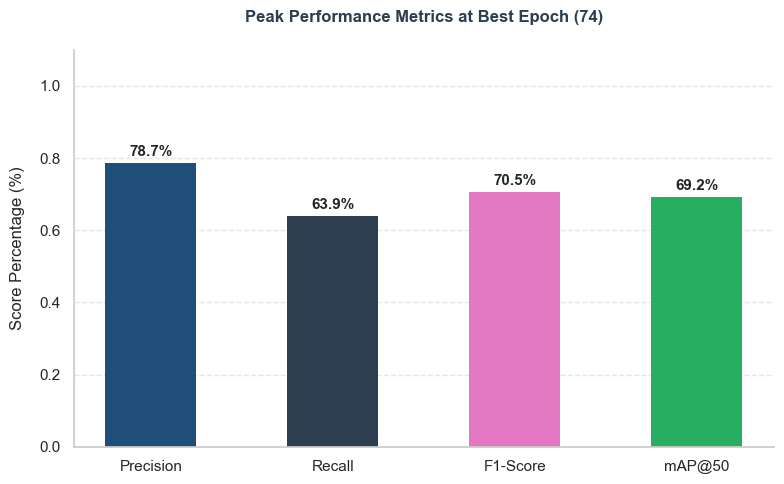

In [20]:
# 1. Identify the best epoch based on the highest mAP50 value
# (YOLO typically uses a combination of mAP50 and mAP50-95, but mAP50 is our primary anchor)
best_epoch_idx = df['metrics/mAP50(B)'].idxmax()
best_row = df.loc[best_epoch_idx]

# Create a clean summary dictionary of the best model's metrics
best_model_stats = {
    'Epoch': int(best_row['epoch']),
    'mAP@50': best_row['metrics/mAP50(B)'],
    'Precision': best_row['metrics/precision(B)'],
    'Recall': best_row['metrics/recall(B)'],
    'F1-Score': best_row['metrics/F1-score'],
    'Train Box Loss': best_row['train/box_loss'],
    'Val Box Loss': best_row['val/box_loss']
}

# 2. Print a beautifully formatted text summary
print("="*50)
print(f"🏆 BEST MODEL PERFORMANCE SUMMARY (Epoch {best_model_stats['Epoch']})")
print("="*50)
for metric, value in best_model_stats.items():
    if metric == 'Epoch': continue
    percentage = "%" if "Loss" not in metric else ""
    multiplier = 100 if "Loss" not in metric else 1
    print(f"🔹 {metric:<15} : {value * multiplier:.2f}{percentage}")
print("="*50)

# 3. Create a professional Bar Chart for the main validation metrics
metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'mAP@50']
values_to_plot = [best_model_stats[m] for m in metrics_to_plot]

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(8, 5))

# Plot vertical bars with a clean, scholarly color palette
colors = ['#1f4e79', '#2c3e50', '#e377c2', '#27ae60']
bars = ax.bar(metrics_to_plot, values_to_plot, color=colors, width=0.5, edgecolor='none')

# Add soft horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')

# 4. Add the exact percentage text labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height*100:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Titles & Axes styling
ax.set_title(f'Peak Performance Metrics at Best Epoch ({best_model_stats["Epoch"]})', pad=20, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Score Percentage (%)', labelpad=10)
ax.set_ylim(0, 1.1) # Give some headroom for text labels

# Remove top and right borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import pandas as pd

# 1. Απομόνωση των τελευταίων 25 εποχών (το "Tail" της εκπαίδευσης)
tail_df = df.tail(25)

print("="*60)
print("📊 ADVANCED STATISTICAL EVALUATION REPORT (Last 25 Epochs)")
print("="*60)

# 2. Υπολογισμός Σταθερότητας (Coefficient of Variation) για το Validation Loss
val_loss_mean = tail_df['val/box_loss'].mean()
val_loss_std = tail_df['val/box_loss'].std()
val_loss_cv = (val_loss_std / val_loss_mean) * 100

print(f"🔹 Validation Box Loss Stability:")
print(f"   - Mean Value (μ): {val_loss_mean:.4f}")
print(f"   - Std Deviation (σ): {val_loss_std:.4f}")
print(f"   - Coeff. of Variation (CV): {val_loss_cv:.2f}%")
if val_loss_cv < 2.0:
    print("   ✅ VERDICT: High Convergence Stability (CV < 2%). The loss tail is perfectly flat.")
else:
    print("   ⚠️ VERDICT: Slight volatility detected in the final epochs.")

print("-"*60)

# 3. 95% Διαστήματα Εμπιστοσύνης για τα βασικά Metrics
for metric_name, csv_col in [('mAP@50', 'metrics/mAP50(B)'), ('F1-Score', 'metrics/F1-score')]:
    metric_mean = tail_df[csv_col].mean()
    metric_std = tail_df[csv_col].std()
    
    # 95% Confidence Interval (Z = 1.96)
    ci_lower = metric_mean - (1.96 * (metric_std / np.sqrt(25)))
    ci_upper = metric_mean + (1.96 * (metric_std / np.sqrt(25)))
    
    print(f"🔹 95% Confidence Interval for {metric_name}:")
    print(f"   - Mean Performance: {metric_mean*100:.2f}%")
    print(f"   - Interval Range:   [{ci_lower*100:.2f}% - {ci_upper*100:.2f}%]")
    print(f"   - Margin of Error:  ±{(metric_upper := ci_upper - metric_mean)*100:.3f}%")
    print("-"*60)

# 4. Στατιστικό εύρος (Min-Max Spread)
map_min = tail_df['metrics/mAP50(B)'].min()
map_max = tail_df['metrics/mAP50(B)'].max()
print(f"🔹 Metric Fluctuation Range (Spread):")
print(f"   - Absolute mAP@50 Spread: {(map_max - map_min)*100:.2f}% (From {map_min*100:.1f}% to {map_max*100:.1f}%)")
print("="*60)

📊 ADVANCED STATISTICAL EVALUATION REPORT (Last 25 Epochs)
🔹 Validation Box Loss Stability:
   - Mean Value (μ): 1.5260
   - Std Deviation (σ): 0.0061
   - Coeff. of Variation (CV): 0.40%
   ✅ VERDICT: High Convergence Stability (CV < 2%). The loss tail is perfectly flat.
------------------------------------------------------------
🔹 95% Confidence Interval for mAP@50:
   - Mean Performance: 67.85%
   - Interval Range:   [67.72% - 67.98%]
   - Margin of Error:  ±0.130%
------------------------------------------------------------
🔹 95% Confidence Interval for F1-Score:
   - Mean Performance: 70.46%
   - Interval Range:   [70.20% - 70.72%]
   - Margin of Error:  ±0.262%
------------------------------------------------------------
🔹 Metric Fluctuation Range (Spread):
   - Absolute mAP@50 Spread: 1.28% (From 67.3% to 68.6%)


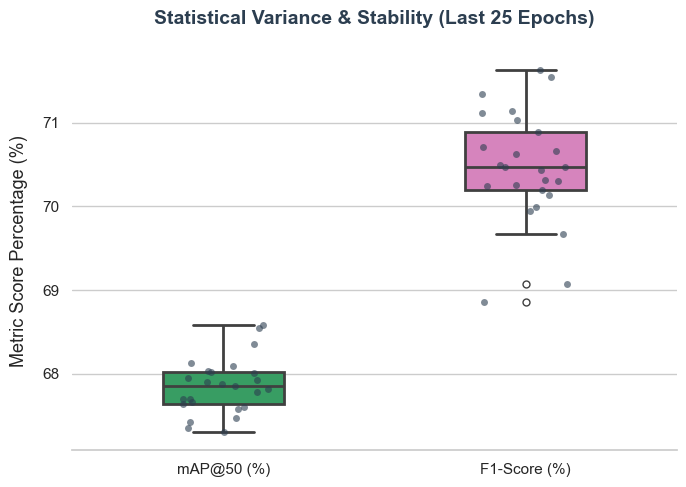

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Προετοιμασία των δεδομένων για το Box Plot
tail_df = df.tail(25).copy()

# Μετατροπή σε ποσοστά (%) για να είναι πιο αναγνώσιμο το γράφημα
data_to_plot = pd.DataFrame({
    'mAP@50 (%)': tail_df['metrics/mAP50(B)'] * 100,
    'F1-Score (%)': tail_df['metrics/F1-score'] * 100
})

# 2. Ρύθμιση ακαδημαϊκού στυλ
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'font.family': 'sans-serif'
})

fig, ax = plt.subplots(figsize=(7, 5))

# 3. Σχεδίαση του Box Plot με custom premium χρώματα
colors = {'mAP@50 (%)': '#27ae60', 'F1-Score (%)': '#e377c2'}
sns.boxplot(
    data=data_to_plot, 
    palette=colors, 
    width=0.4, 
    linewidth=2,
    fliersize=5,
    ax=ax
)

# Προσθήκη Swarmplot από πάνω για να φαίνονται οι ακριβείς 25 κουκκίδες (εποχές)
sns.stripplot(
    data=data_to_plot, 
    color='#2c3e50', 
    size=5, 
    alpha=0.6, 
    jitter=0.15,
    ax=ax
)

# Τίτλοι και ονομασίες αξόνων
ax.set_title('Statistical Variance & Stability (Last 25 Epochs)', pad=20, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Metric Score Percentage (%)', labelpad=10)

# Αισθητική βελτίωση των "συνόρων"
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()